# Customer Segmentation using K-Means Clustering

## Internship Project

### Objective

The objective of this project is to segment customers into different groups based on their characteristics using the K-Means Clustering algorithm. Customer segmentation helps businesses understand customer behavior, identify high-value customers, and develop targeted marketing strategies.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

### Dataset
Shopping Mall Customer Segmentation Dataset from Keggle

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("Shopping Mall Customer Segmentation Data .csv")

df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [19]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 15079
Columns: 6


## Dataset Overview

Before applying machine learning techniques, it is important to understand the dataset by examining its structure, checking for missing values, identifying duplicate records, and reviewing summary statistics.

In [20]:
# Display the shape of the dataset
df.shape

(15079, 6)

In [21]:
# Display column names
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Annual Income', 'Spending Score',
       'Cluster'],
      dtype='str')

In [22]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer ID     15079 non-null  str  
 1   Age             15079 non-null  int64
 2   Gender          15079 non-null  str  
 3   Annual Income   15079 non-null  int64
 4   Spending Score  15079 non-null  int64
 5   Cluster         15079 non-null  int32
dtypes: int32(1), int64(3), str(2)
memory usage: 648.1 KB


In [23]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [24]:
# Summary statistics
df.describe()

,Age,Annual Income,Spending Score,Cluster
count,15079.000000,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617,2.064394
std,21.119207,52249.425866,28.726977,1.415959
min,18.000000,20022.000000,1.000000,0.000000
25%,36.000000,64141.000000,26.000000,1.000000
50%,54.000000,109190.000000,51.000000,2.000000
75%,72.000000,155008.000000,75.000000,3.000000
max,90.000000,199974.000000,100.000000,4.000000


In [25]:
# Remove duplicate records if any
df = df.drop_duplicates()

# Verify dataset information after cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer ID     15079 non-null  str  
 1   Age             15079 non-null  int64
 2   Gender          15079 non-null  str  
 3   Annual Income   15079 non-null  int64
 4   Spending Score  15079 non-null  int64
 5   Cluster         15079 non-null  int32
dtypes: int32(1), int64(3), str(2)
memory usage: 648.1 KB


## __Exploratory Data Analysis__

Exploratory Data Analysis helps us understand the distribution of customer characteristics such as age, annual income, and spending score before performing clustering.

### __Age Distribution__ 

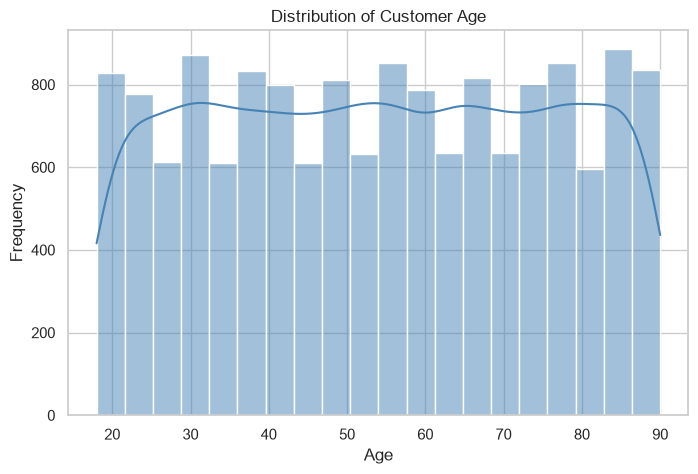

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True, color="steelblue")

plt.title("Distribution of Customer Age")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### Observation

- Customer ages range from 18 to 90 years.
- The distribution is fairly uniform across different age groups.
- There is no single age group that dominates the dataset.
- This wide age range makes age an important feature for customer segmentation.

### __Annual Income Distribution__ 

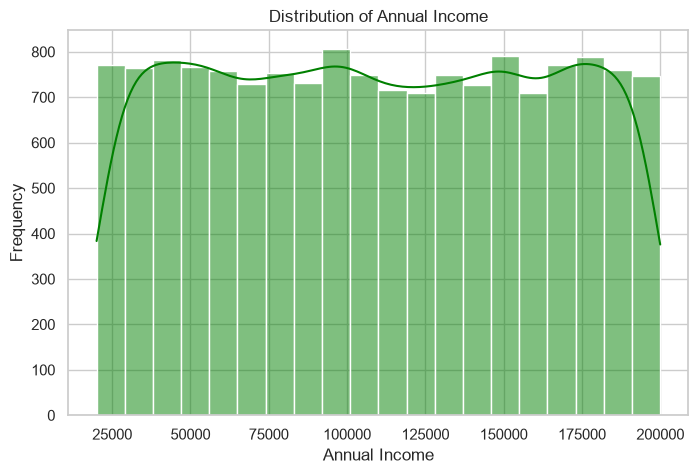

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income"], bins=20, kde=True, color="green")

plt.title("Distribution of Annual Income")

plt.xlabel("Annual Income")

plt.ylabel("Frequency")

plt.show()

### Observation

- Annual income ranges from approximately 20,000 to 200,000.
- Customers are distributed across low, medium, and high income levels.
- The dataset contains a diverse range of income groups, making it suitable for clustering.

### __Spending Score Distribution__ 

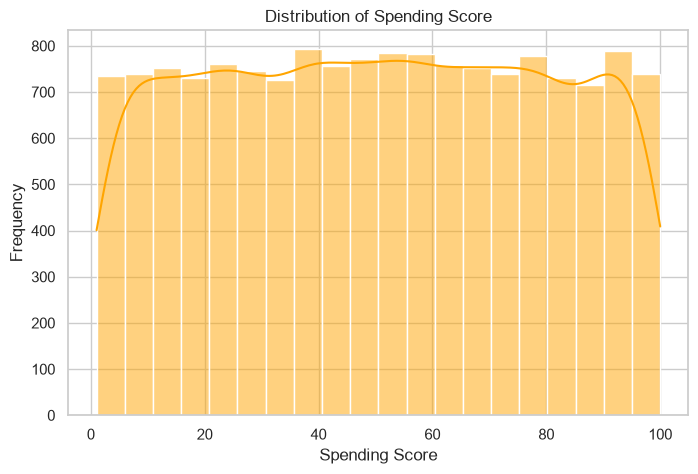

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score"], bins=20, kde=True, color="orange")

plt.title("Distribution of Spending Score")

plt.xlabel("Spending Score")

plt.ylabel("Frequency")

plt.show()

### Observation

- Spending scores range from 1 to 100.
- Customers are spread across the full spending score range.
- This variation makes spending score one of the most important features for identifying customer segments.

## __Feature Selection__

Customer segmentation will be performed using numerical features that describe customer characteristics. The selected features are Age, Annual Income, and Spending Score.

In [29]:
# Select features for clustering

X = df[["Age", "Annual Income", "Spending Score"]]

X.head()

,Age,Annual Income,Spending Score
0,30,151479,89
1,58,185088,95
2,62,70912,76
3,23,55460,57
4,24,153752,76


## __Feature Scaling__

Feature scaling ensures that all variables contribute equally to the clustering process by transforming them to a common scale.

In [30]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.14551615,  0.79881267,  1.33705873],
       [ 0.18033514,  1.44207552,  1.54592857],
       [ 0.36974247, -0.74320756,  0.88450743],
       [-1.47697897, -1.03895267,  0.2230863 ],
       [-1.42962714,  0.84231698,  0.88450743]])

## __Elbow Method__

The Elbow Method is used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS).

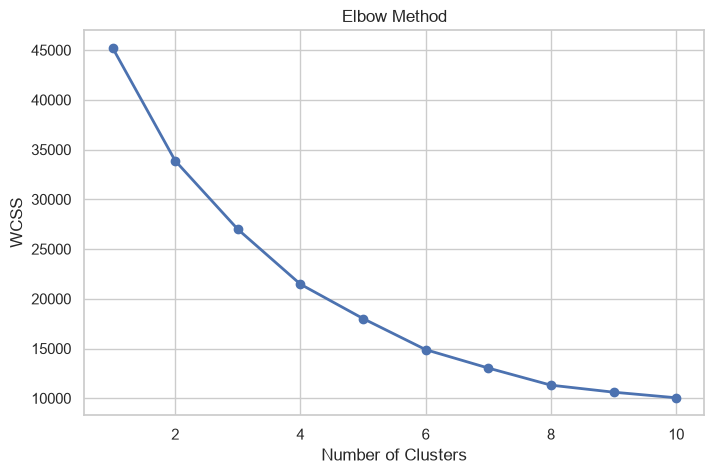

In [31]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### __Observation__

- The WCSS decreases as the number of clusters increases.
- The point where the curve begins to flatten is considered the optimal number of clusters.
- This point represents a balance between minimizing within-cluster variation and avoiding unnecessary clusters.

## __K-Means Clustering__

K-Means clustering groups customers with similar characteristics into distinct clusters. Based on the Elbow Method, we use **5 clusters** for customer segmentation.

In [32]:
# Apply K-Means with 5 clusters

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score,Cluster
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89,1
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95,0
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76,3
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57,2
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76,1


## Cluster Distribution

This section shows the number of customers assigned to each cluster.

In [33]:
# Number of customers in each cluster

df["Cluster"].value_counts().sort_index()

Cluster
0    2714
1    3295
2    2600
3    3246
4    3224
Name: count, dtype: int64

## Customer Segments

The scatter plot below visualizes customer groups based on Annual Income and Spending Score.

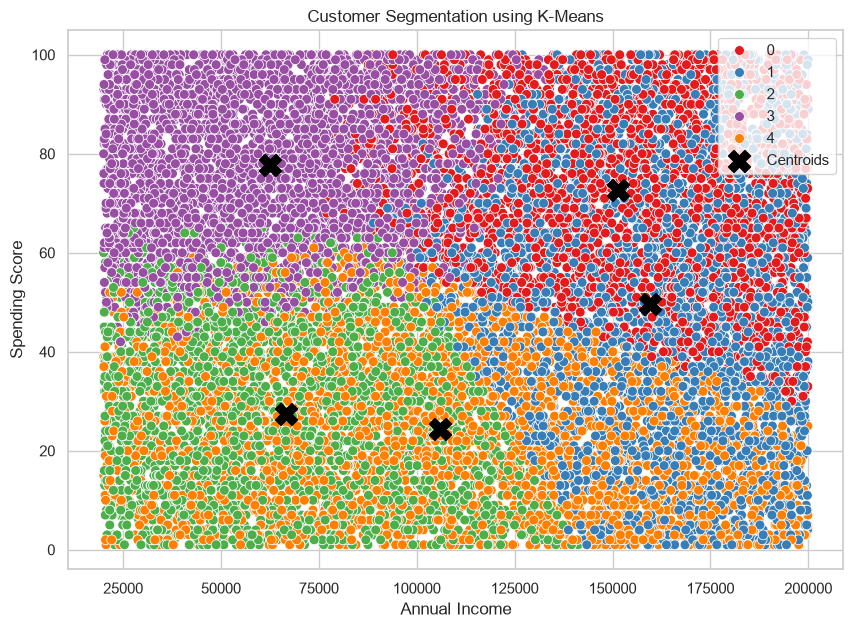

In [38]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income",
    y="Spending Score",
    hue="Cluster",
    palette="Set1",
    s=50
)

plt.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:,1],
    scaler.inverse_transform(kmeans.cluster_centers_)[:,2],
    s=250,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.legend()

plt.show()

In [39]:
cluster_summary = (
    df.groupby("Cluster")[["Age", "Annual Income", "Spending Score"]]
      .mean()
      .round(2)
)

cluster_summary

,Age,Annual Income,Spending Score
Cluster,,,
0,71.65,151668.09,72.60
1,34.97,159418.10,49.59
2,37.27,66538.33,27.49
3,52.72,62648.25,77.80
4,74.27,105938.96,24.33


## Cluster Analysis

### Observation

- Customers have been successfully divided into five distinct groups.
- Each cluster has unique characteristics based on age, annual income, and spending score.
- Some clusters contain high-income, high-spending customers, while others represent low-spending or budget-conscious customers.
- These customer segments can help businesses design personalized marketing campaigns and improve customer engagement.

## __Cluster Interpretation__

The K-Means algorithm divided customers into five meaningful segments.

### Premium Customers
- Senior customers
- High annual income
- High spending score
- Represents premium and loyal customers.

### High Income Moderate Spenders
- Young customers
- Highest annual income
- Moderate spending
- Customers with strong purchasing power but average buying behaviour.

### Budget Customers
- Young to middle-aged customers
- Lower annual income
- Low spending score
- Price-sensitive and budget-conscious customers.

### Active Shoppers
- Middle-aged customers
- Moderate income
- High spending score
- Active shoppers who frequently purchase despite moderate income.

### Conservative Seniors
- Senior customers
- Moderate to high income
- Low spending score
- Customers with good income but conservative spending habits.

## __Business Recommendations__

- Offer premium membership and exclusive rewards to Cluster 0 customers.
- Encourage Cluster 1 customers to spend more through personalized discounts and loyalty programs.
- Provide affordable offers and seasonal discounts for Cluster 2 customers.
- Recommend premium products and cross-selling opportunities to Cluster 3 customers.
- Re-engage Cluster 4 customers with targeted promotions and personalized marketing campaigns.

## __Conclusion__

Customer segmentation using the K-Means clustering algorithm successfully grouped customers into five distinct segments based on Age, Annual Income, and Spending Score.

The analysis provides valuable insights into customer behaviour and purchasing patterns. Businesses can use these customer segments to design targeted marketing strategies, improve customer satisfaction, and increase overall revenue through personalized promotions and services.